In [1]:
import os
import pandas as pd

# Check if the uploaded file exists and look at its head
file_path = "./result/new_molecules_file_by_compared_pocket_similarity_refined_filter.csv"
if os.path.exists(file_path):
    df = pd.read_csv(file_path, nrows=5)
    print("Columns:", df.columns)
    print(df.head())
else:
    print("File not found")

try:
    import rdkit
    print("rdkit version:", rdkit.__version__)
except ImportError:
    print("rdkit not installed")

Columns: Index(['id', 'frag1', 'frag2', 'new_smiles'], dtype='object')
   id                              frag1  \
0   1    *NC[C@@H]1CCCC[C@H]1CCOc1cccnc1   
1   2          *C(=O)c1cnn(-c2ccccc2)c1N   
2   3                                *CO   
3   4  *C(=O)[C@@H]1CN2C(=O)CCN2C12CCCC2   
4   5      *N1CCN(c2ncnc3sc(CCF)cc23)CC1   

                                      frag2  \
0               *C(=O)Cc1c[nH]c2ccc(OC)cc12   
1        *C(=O)c1cc(NC(=O)C=Cc2ccccc2)ccc1C   
2  *c1ccc2ncn(-c3ccc(N4CCOCC4)cc3)c(=O)c2c1   
3                              *c1cnc(N)nc1   
4                     *c1cc(OC)c(OC)c(OC)c1   

                                          new_smiles  
0  COc1ccc2[nH]cc(CC(=O)NC[C@@H]3CCCC[C@H]3CCOc3c...  
1  Cc1ccc(NC(=O)C=Cc2ccccc2)cc1C(=O)C(=O)c1cnn(-c...  
2            O=c1c2cc(CO)ccc2ncn1-c1ccc(N2CCOCC2)cc1  
3        Nc1ncc(C(=O)[C@@H]2CN3C(=O)CCN3C23CCCC3)cn1  
4     COc1cc(N2CCN(c3ncnc4sc(CCF)cc34)CC2)cc(OC)c1OC  
rdkit version: 2023.09.6


In [2]:
import sys
import os
try:
    from rdkit.Chem import RDConfig
    sascorer_path = os.path.join(RDConfig.RDBASE, 'Contrib', 'SA_Score')
    sys.path.append(sascorer_path)
    import sascorer
    print("sascorer imported successfully!")
    print(dir(sascorer))
except Exception as e:
    print("Error importing sascorer:", e)

Error importing sascorer: module 'rdkit.RDConfig' has no attribute 'RDBASE'


In [3]:
import rdkit
try:
    from rdkit import RDConfig
    print("RDConfig attributes:")
    print(dir(RDConfig))
except Exception as e:
    print("Error:", e)

RDConfig attributes:
['ObsoleteCodeError', 'RDCodeDir', 'RDContribDir', 'RDDataDatabase', 'RDDataDir', 'RDDocsDir', 'RDProjDir', 'RDTestDatabase', 'UnimplementedCodeError', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'defaultDBPassword', 'defaultDBUser', 'molViewer', 'os', 'pythonExe', 'pythonTestCommand', 'rdkit', 'rpcTestPort', 'sqlite3', 'sys', 'usePgSQL', 'useSqlLite']


In [4]:
import os
import sys
from rdkit import RDConfig

sascorer_path = os.path.join(RDConfig.RDContribDir, 'SA_Score')
print("sascorer_path:", sascorer_path)

if os.path.exists(sascorer_path):
    print("Files in sascorer path:", os.listdir(sascorer_path))
    sys.path.append(sascorer_path)
    import sascorer
    print("sascorer imported successfully!")
    print(dir(sascorer))
else:
    print("sascorer path not found")

sascorer_path: /data/Software/anaconda3/envs/CADD_Agent/lib/python3.11/site-packages/rdkit/Contrib/SA_Score
Files in sascorer path: ['data', 'UnitTestSAScore.py', 'sascorer.py', '__pycache__', 'README', 'fpscores.pkl.gz']
sascorer imported successfully!
['Chem', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_fscores', 'calculateScore', 'defaultdict', 'math', 'numBridgeheadsAndSpiro', 'op', 'pickle', 'processMols', 'rdMolDescriptors', 'readFragmentScores']


In [5]:
import sys, os
from rdkit import RDConfig
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer
from rdkit import Chem

mol = Chem.MolFromSmiles('COc1ccc2[nH]cc(CC(=O)NC[C@@H]3CCCC[C@H]3CCOc3cccnc3)c2c1')
if mol:
    score = sascorer.calculateScore(mol)
    print("SA score:", score)

    # Can we get the components?
    import inspect
    print(inspect.getsource(sascorer.calculateScore))

SA score: 3.161960690272563
def calculateScore(m):
  if _fscores is None:
    readFragmentScores()

  # fragment score
  fp = rdMolDescriptors.GetMorganFingerprint(m,
                                             2)  # <- 2 is the *radius* of the circular fingerprint
  fps = fp.GetNonzeroElements()
  score1 = 0.
  nf = 0
  for bitId, v in fps.items():
    nf += v
    sfp = bitId
    score1 += _fscores.get(sfp, -4) * v
  score1 /= nf

  # features score
  nAtoms = m.GetNumAtoms()
  nChiralCenters = len(Chem.FindMolChiralCenters(m, includeUnassigned=True))
  ri = m.GetRingInfo()
  nBridgeheads, nSpiro = numBridgeheadsAndSpiro(m, ri)
  nMacrocycles = 0
  for x in ri.AtomRings():
    if len(x) > 8:
      nMacrocycles += 1

  sizePenalty = nAtoms**1.005 - nAtoms
  stereoPenalty = math.log10(nChiralCenters + 1)
  spiroPenalty = math.log10(nSpiro + 1)
  bridgePenalty = math.log10(nBridgeheads + 1)
  macrocyclePenalty = 0.
  # ---------------------------------------
  # This differs from the pa

In [12]:
import sys, os
from rdkit import RDConfig
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer
import math
from rdkit import Chem

def calculate_sascore_components(m):
    """
    计算并拆分分子的 SAscore 及其子项
    返回: (Final_SAscore, Fragments_Score, Complexity_Score)
    已增加对旧版 RDKit 的兼容性
    """
    if not m.GetNumAtoms():
        return None, None, None

    # 初始化片段字典
    if sascorer._fscores is None:
        sascorer.readFragmentScores()

    # ---------------- 兼容性修复区域 ----------------
    # 1. 计算片段得分 (Fragments Score)
    # 如果是新版 RDKit，使用 mfpgen；如果是旧版，使用 rdMolDescriptors
    if hasattr(sascorer, 'mfpgen'):
        sfp = sascorer.mfpgen.GetSparseCountFingerprint(m)
    else:
        from rdkit.Chem import rdMolDescriptors
        # SA score 的原始论文中规定使用 Morgan Fingerprint, 半径(Radius) = 2
        sfp = rdMolDescriptors.GetMorganFingerprint(m, 2)
    # ------------------------------------------------

    score1 = 0.
    nf = 0
    nze = sfp.GetNonzeroElements()
    for id, count in nze.items():
        nf += count
        score1 += sascorer._fscores.get(id, -4) * count
    score1 /= nf if nf > 0 else 1

    # 2. 计算复杂度得分 (Complexity Score)
    nAtoms = m.GetNumAtoms()
    nChiralCenters = len(Chem.FindMolChiralCenters(m, includeUnassigned=True))
    ri = m.GetRingInfo()
    nBridgeheads, nSpiro = sascorer.numBridgeheadsAndSpiro(m, ri)
    nMacrocycles = sum(1 for x in ri.AtomRings() if len(x) > 8)

    sizePenalty = nAtoms**1.005 - nAtoms
    stereoPenalty = math.log10(nChiralCenters + 1)
    spiroPenalty = math.log10(nSpiro + 1)
    bridgePenalty = math.log10(nBridgeheads + 1)
    macrocyclePenalty = math.log10(2) if nMacrocycles > 0 else 0.

    score2 = 0. - sizePenalty - stereoPenalty - spiroPenalty - bridgePenalty - macrocyclePenalty

    # 指纹密度矫正
    score3 = math.log(float(nAtoms) / len(nze)) * .5 if nAtoms > len(nze) else 0.

    # 3. 计算最终的 SAscore 标度转换
    sascore_raw = score1 + score2 + score3
    min_val, max_val = -4.0, 2.5
    sascore = 11. - (sascore_raw - min_val + 1) / (max_val - min_val) * 9.

    # 平滑处理极值
    if sascore > 8.: sascore = 8. + math.log(sascore + 1. - 9.)
    if sascore > 10.: sascore = 10.0
    elif sascore < 1.: sascore = 1.0

    return sascore, score1, score2 + score3

mol = Chem.MolFromSmiles('COc1ccc2[nH]cc(CC(=O)NC[C@@H]3CCCC[C@H]3CCOc3cccnc3)c2c1')
print(calculate_sascore_components(mol))

(3.161960690272563, 1.674791208791209, -1.0139850406547273)


In [1]:
#

开始处理文件并计算分子属性...
正在读取 compared_pocket_similarity ...
正在读取 key_aas_similarity ...
正在读取 pocket_seq_similarity ...
正在读取 pocket_similarity ...
正在读取 decorator ...
所有属性计算完成，共包含 50000 个有效分子。正在绘制图表...
对比图已成功保存为: 5_metrics_methods_comparison_plot.png


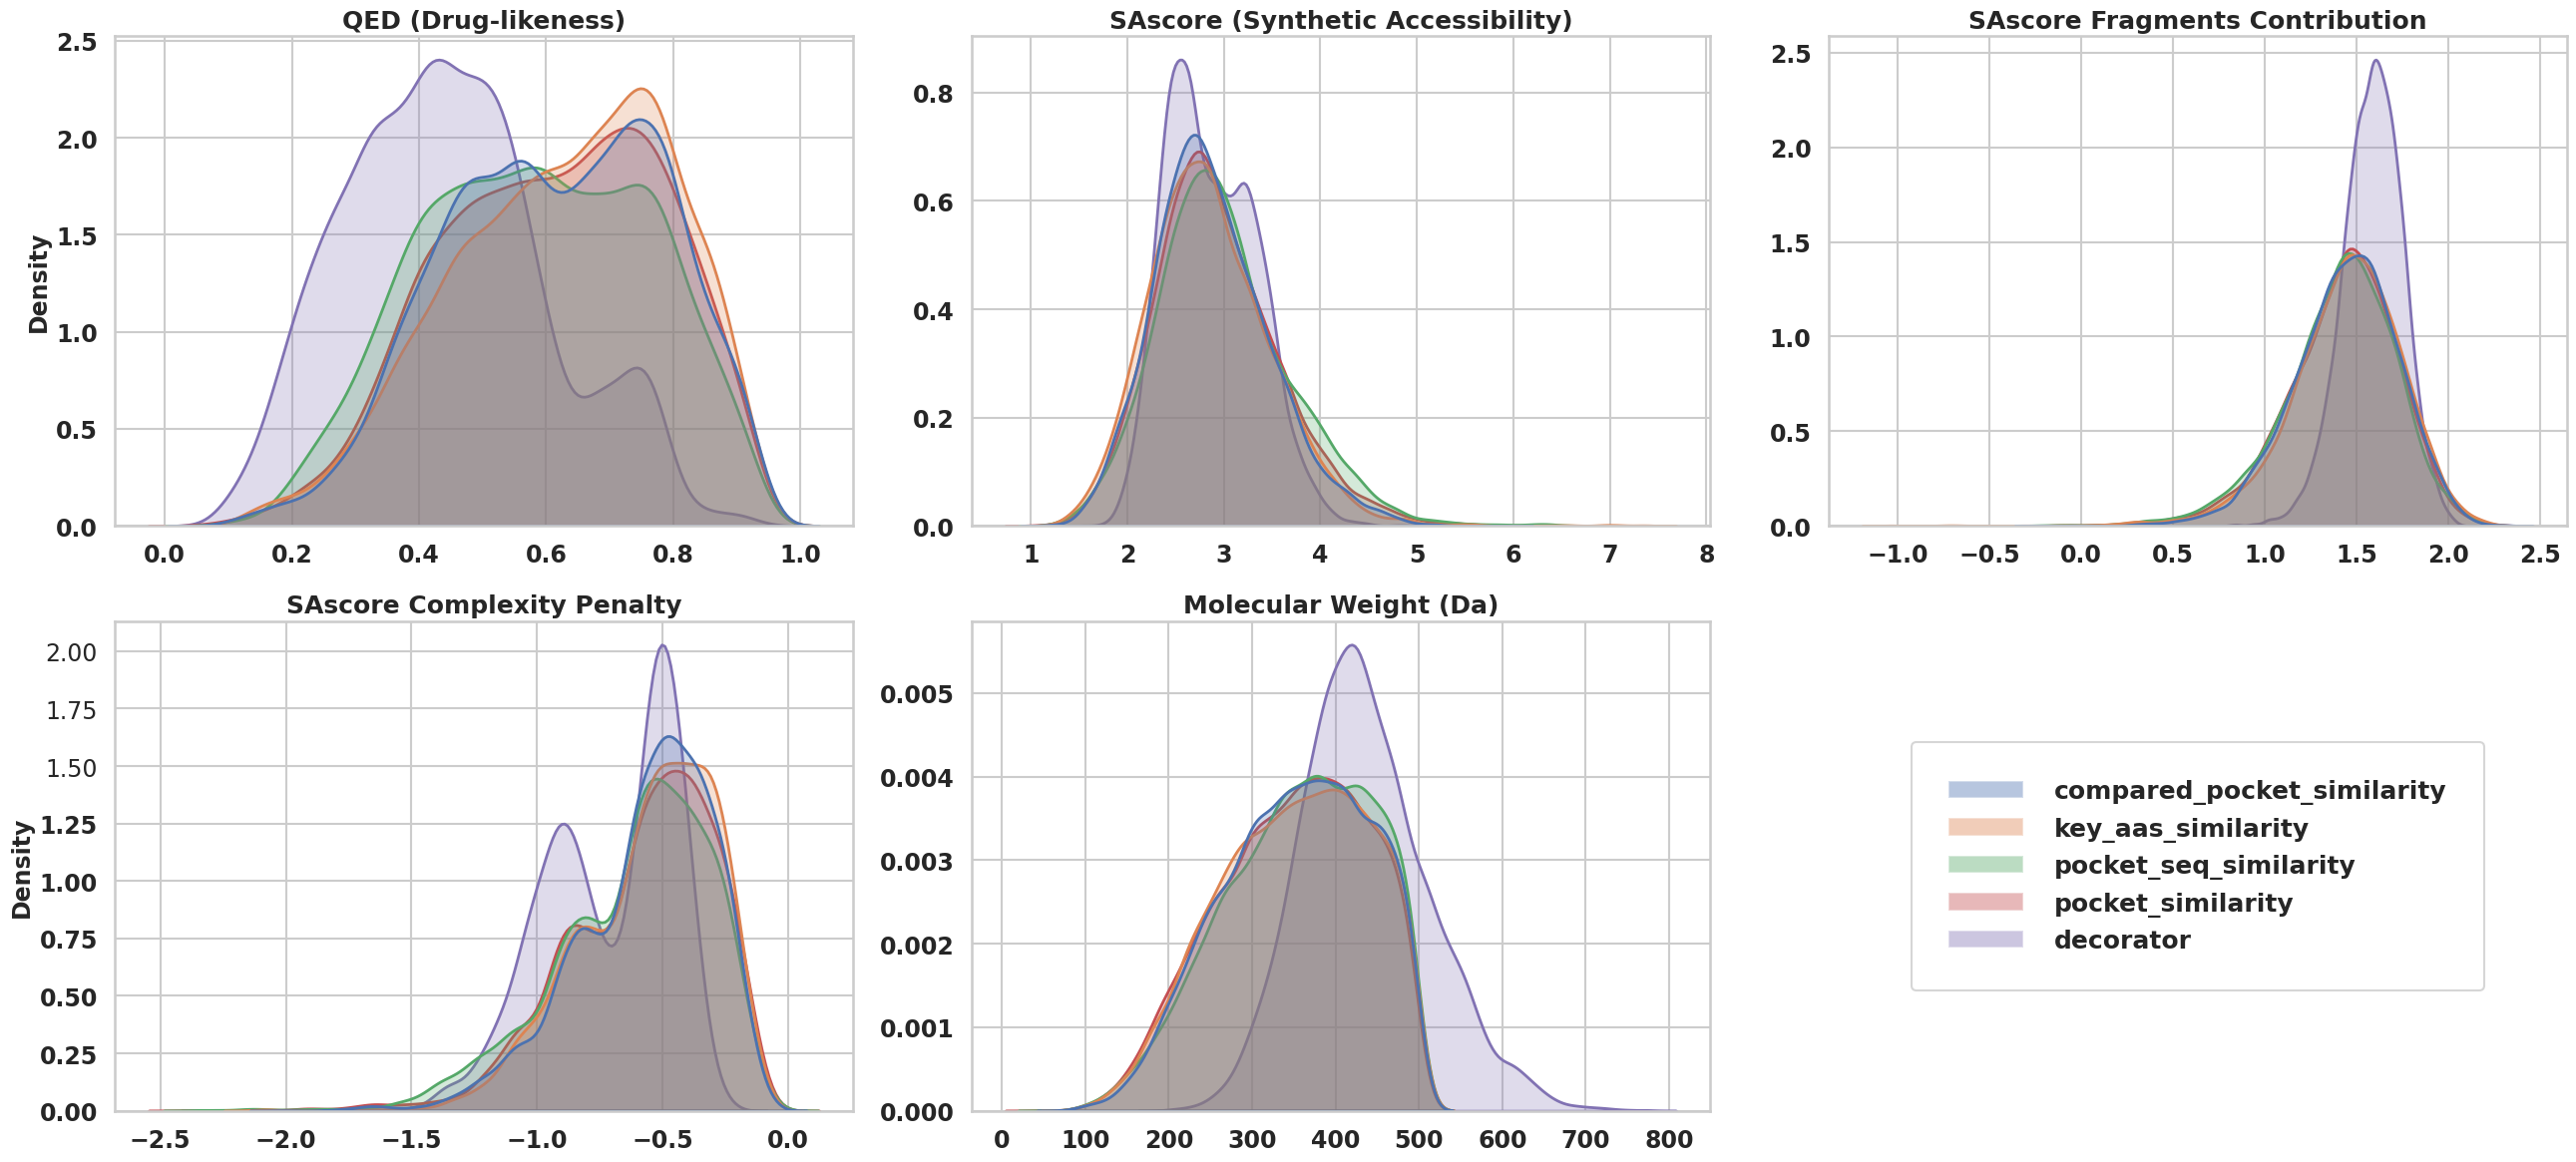

In [30]:
import sys, os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from rdkit import RDConfig

# 确保能加载 RDKit 提供的 SAScorer
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

def calculate_sascore_components(m):
    """计算并拆分分子的 SAscore 及其子项"""
    if not m.GetNumAtoms():
        return None, None, None

    if sascorer._fscores is None:
        sascorer.readFragmentScores()

    # 兼容不同版本的 RDKit 指纹计算
    if hasattr(sascorer, 'mfpgen'):
        sfp = sascorer.mfpgen.GetSparseCountFingerprint(m)
    else:
        from rdkit.Chem import rdMolDescriptors
        sfp = rdMolDescriptors.GetMorganFingerprint(m, 2)

    # 1. 计算片段得分 (Fragments Score)
    score1 = 0.
    nf = 0
    nze = sfp.GetNonzeroElements()
    for id, count in nze.items():
        nf += count
        score1 += sascorer._fscores.get(id, -4) * count
    score1 /= nf if nf > 0 else 1

    # 2. 计算复杂度得分 (Complexity Score)
    nAtoms = m.GetNumAtoms()
    nChiralCenters = len(Chem.FindMolChiralCenters(m, includeUnassigned=True))
    ri = m.GetRingInfo()
    nBridgeheads, nSpiro = sascorer.numBridgeheadsAndSpiro(m, ri)
    nMacrocycles = sum(1 for x in ri.AtomRings() if len(x) > 8)

    sizePenalty = nAtoms**1.005 - nAtoms
    stereoPenalty = math.log10(nChiralCenters + 1)
    spiroPenalty = math.log10(nSpiro + 1)
    bridgePenalty = math.log10(nBridgeheads + 1)
    macrocyclePenalty = math.log10(2) if nMacrocycles > 0 else 0.

    score2 = 0. - sizePenalty - stereoPenalty - spiroPenalty - bridgePenalty - macrocyclePenalty
    score3 = math.log(float(nAtoms) / len(nze)) * .5 if nAtoms > len(nze) else 0.

    # 3. 计算最终的 SAscore 标度转换
    sascore_raw = score1 + score2 + score3
    min_val, max_val = -4.0, 2.5
    sascore = 11. - (sascore_raw - min_val + 1) / (max_val - min_val) * 9.

    if sascore > 8.: sascore = 8. + math.log(sascore + 1. - 9.)
    if sascore > 10.: sascore = 10.0
    elif sascore < 1.: sascore = 1.0

    return sascore, score1, score2 + score3

def main():
    # 5 个文件及其对应的图例标签（键名就是绘图图例文字）
    files = {
        "compared_pocket_similarity": "./result/new_molecules_file_by_compared_pocket_similarity_refined_filter_10000.csv",
        "key_aas_similarity": "./result/new_molecules_file_by_keyaas_overlap_filter_10000.csv",
        "pocket_seq_similarity": "./result/new_molecules_file_by_pocket_seq_similarity_filter_10000.csv",
        "pocket_similarity": "./result/new_molecules_file_by_pocket_similarity_filter_10000.csv",
        "decorator": "./result/random_sample_gen_by_decorator_10000.csv"
    }
    method_names = list(files.keys())  # 固定图例顺序

    all_results = []

    print("开始处理文件并计算分子属性...")
    for label, fpath in files.items():
        if os.path.exists(fpath):
            print(f"正在读取 {label} ...")
            df = pd.read_csv(fpath)

            # 遍历每个分子的 SMILES，过滤掉空值
            for smi in df['new_smiles'].dropna():
                mol = Chem.MolFromSmiles(smi)
                if mol:
                    # 接收三个拆分的 SA 分数
                    sa, sa_frag, sa_comp = calculate_sascore_components(mol)
                    all_results.append({
                        'Method': label,
                        'SAscore': sa,
                        'SA_Fragments': sa_frag,
                        'SA_Complexity': sa_comp,
                        'QED': QED.qed(mol),
                        'MolWeight': Descriptors.MolWt(mol),
                    })
        else:
            print(f"警告: 找不到文件 {fpath}")

    # 将所有结果合并成一个 DataFrame
    df_res = pd.DataFrame(all_results)
    print(f"所有属性计算完成，共包含 {len(df_res)} 个有效分子。正在绘制图表...")

    # 设置绘图风格 + 固定配色，保证图例颜色一一对应
    sns.set(style="whitegrid", context="talk")
    palette = sns.color_palette(n_colors=len(method_names))
    color_map = dict(zip(method_names, palette))

    # 创建 2 行 4 列的子图画布 (共 8 个格子)
    fig, axes = plt.subplots(2, 3, figsize=(26, 12))
    axes = axes.flatten()

    # 定义要绘制的属性列和标题 (现在是 7 个指标)
    metrics = [
        ('QED', 'QED (Drug-likeness)'),
        ('SAscore', 'SAscore (Synthetic Accessibility)'),
        ('SA_Fragments', 'SAscore Fragments Contribution'),
        ('SA_Complexity', 'SAscore Complexity Penalty'),
        ('MolWeight', 'Molecular Weight (Da)'),
    ]

    # 循环绘制 7 个属性的分布图
    for i, (col, title) in enumerate(metrics):
        sns.kdeplot(
            data=df_res,
            x=col,
            hue='Method',
            palette=color_map,  # 强制固定配色映射
            fill=True,
            alpha=0.25,
            ax=axes[i],
            linewidth=2,
            common_norm=False
        )
        axes[i].set_title(title, fontsize=18, fontweight='bold')

        ylab_text = 'Density' if i % 3 == 0 else ''
        axes[i].set_ylabel(ylab_text, fontweight='bold', fontsize=17)
        # X轴标签（这里是空，如需显示x轴名称可自行添加）
        axes[i].set_xlabel('', fontweight='bold')
        axes[i].tick_params(axis='both', labelsize=17)
        for tick_text in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            tick_text.set_fontweight('bold')
        # 移除每个子图自带的图例，避免重复
        leg = axes[i].get_legend()
        if leg:
            leg.remove()

    # 利用第 8 个空白子图作为统一图例的区域 (索引为 7)
    axes[5].axis('off')
    # 手动创建图例patch，不再依赖子图抓取
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[name], alpha=0.4, label=name) for name in method_names]
    axes[5].legend(
        handles=legend_elements,
        loc='center',
        fontsize=18,
        prop={'weight': 'bold', 'size': 18},
        title_fontsize=20,
        frameon=True,
        handletextpad=1.2,  # 色块与文字间距拉大
        handlelength=3.0,   # 放大图例色块长度
        borderpad=1.5
    )

    plt.tight_layout()

    # 保存图像
    output_path = "5_metrics_methods_comparison_plot.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"对比图已成功保存为: {output_path}")

if __name__ == "__main__":
    main()

开始处理文件并计算分子属性...
正在读取 compared_pocket_similarity ...
正在读取 key_aas_similarity ...
正在读取 pocket_seq_similarity ...
正在读取 pocket_similarity ...
正在读取 decorator ...
所有属性计算完成，共包含 50000 个有效分子。正在绘制图表...
对比图已成功保存为: 5_metrics_methods_comparison_plot2.png


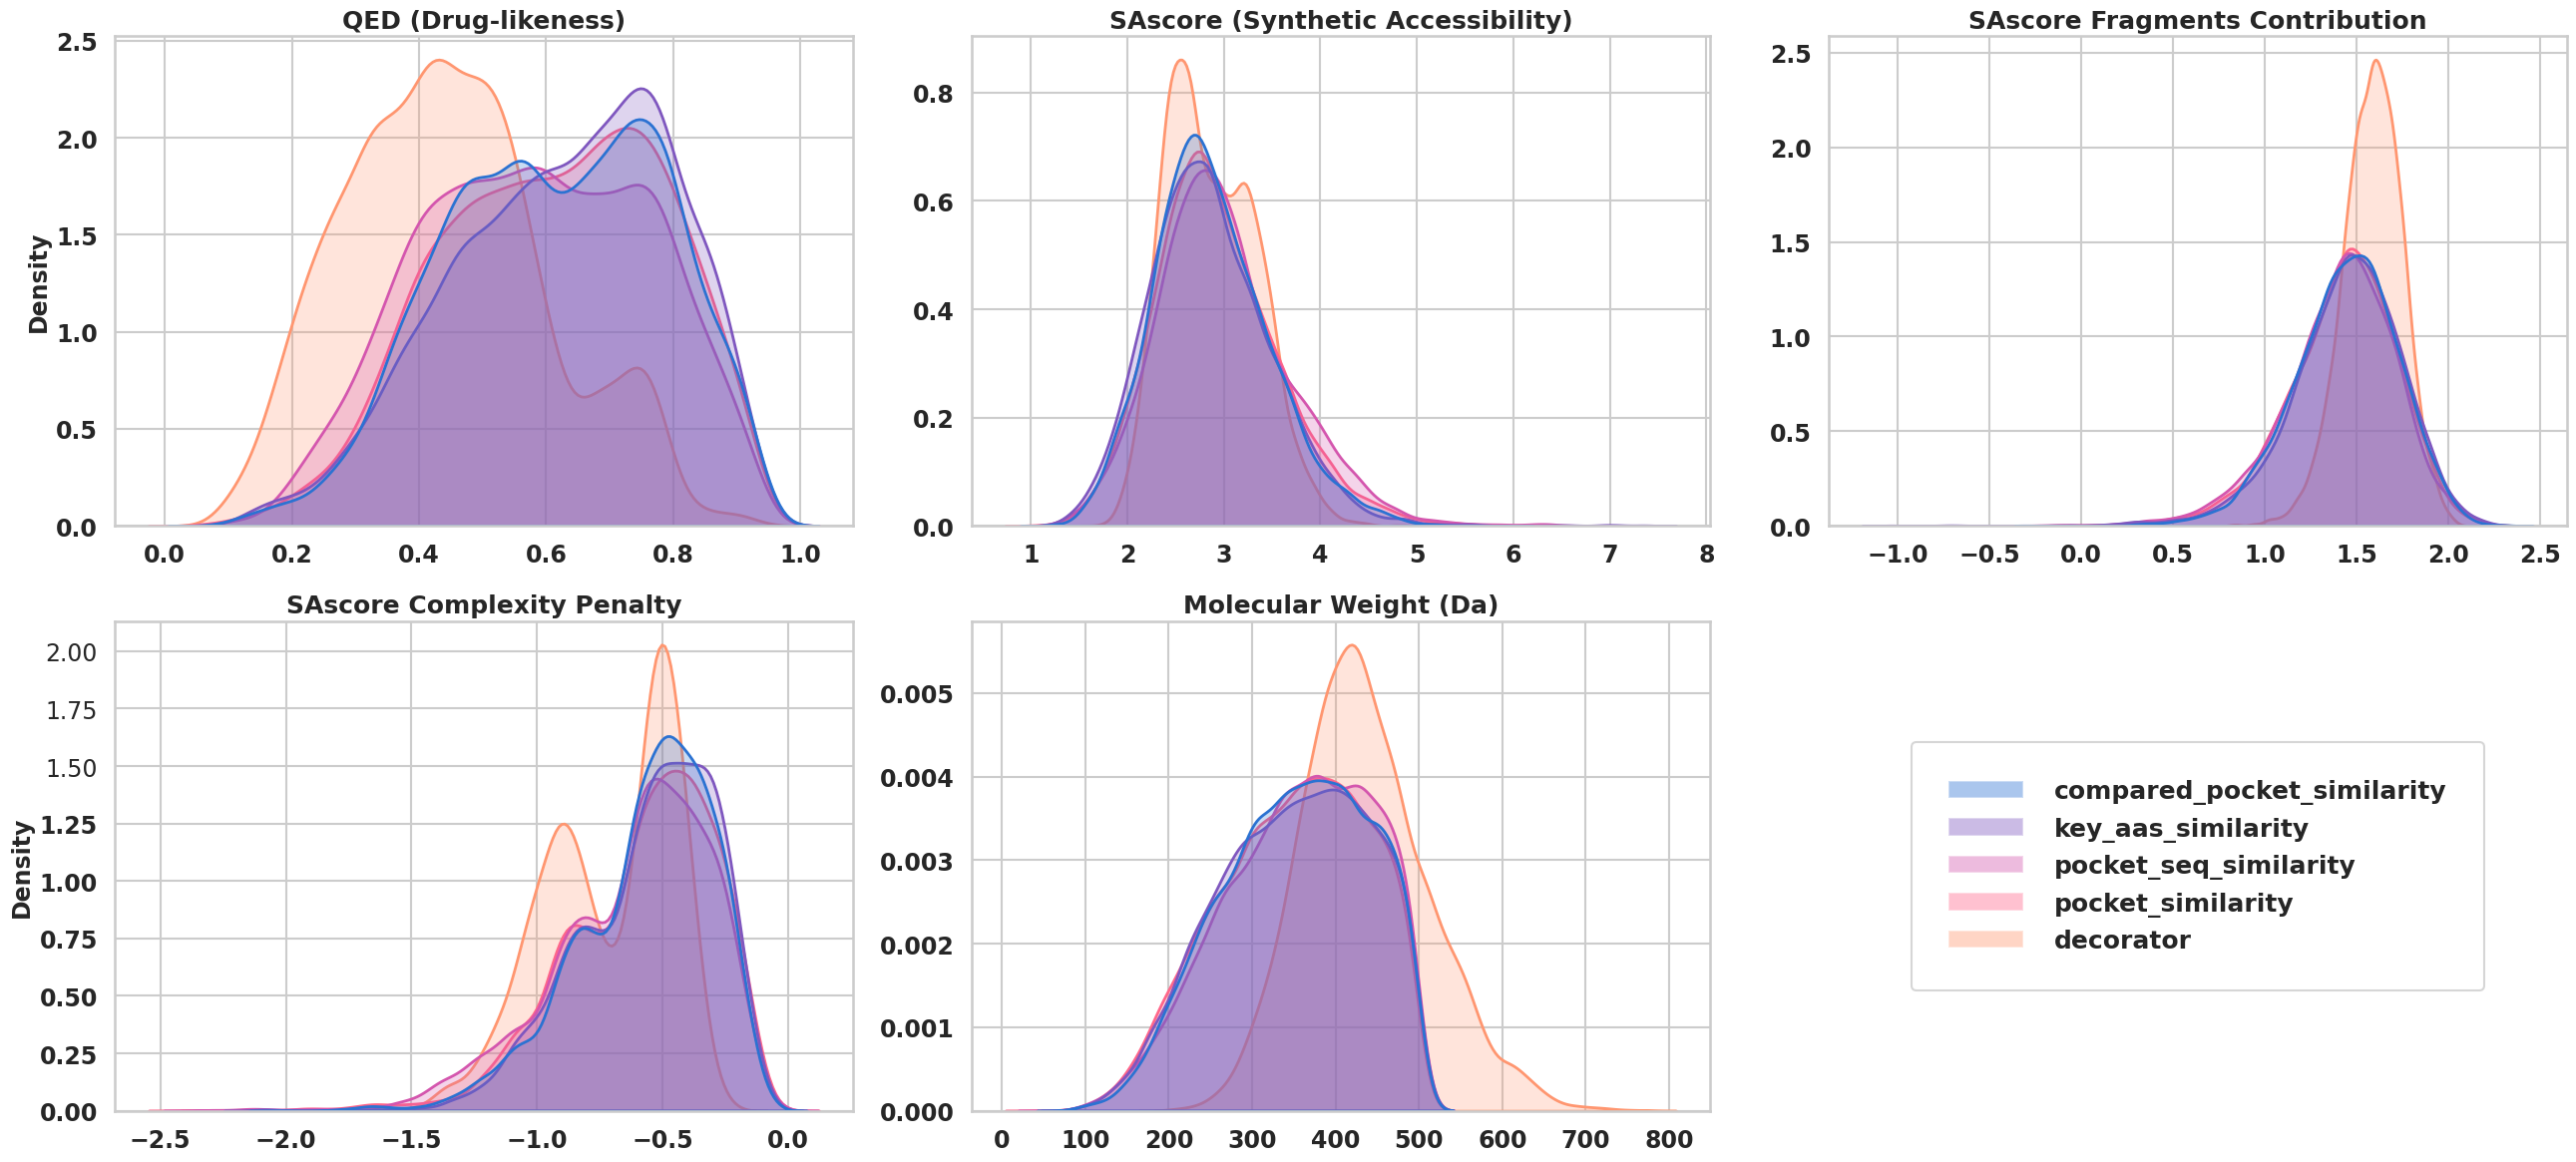

In [31]:
import sys, os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from rdkit import RDConfig
from matplotlib.patches import Patch

# 确保能加载 RDKit 提供的 SAScorer
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

def calculate_sascore_components(m):
    """计算并拆分分子的 SAscore 及其子项"""
    if not m.GetNumAtoms():
        return None, None, None

    if sascorer._fscores is None:
        sascorer.readFragmentScores()

    # 兼容不同版本的 RDKit 指纹计算
    if hasattr(sascorer, 'mfpgen'):
        sfp = sascorer.mfpgen.GetSparseCountFingerprint(m)
    else:
        from rdkit.Chem import rdMolDescriptors
        sfp = rdMolDescriptors.GetMorganFingerprint(m, 2)

    # 1. 计算片段得分 (Fragments Score)
    score1 = 0.
    nf = 0
    nze = sfp.GetNonzeroElements()
    for id, count in nze.items():
        nf += count
        score1 += sascorer._fscores.get(id, -4) * count
    score1 /= nf if nf > 0 else 1

    # 2. 计算复杂度得分 (Complexity Score)
    nAtoms = m.GetNumAtoms()
    nChiralCenters = len(Chem.FindMolChiralCenters(m, includeUnassigned=True))
    ri = m.GetRingInfo()
    nBridgeheads, nSpiro = sascorer.numBridgeheadsAndSpiro(m, ri)
    nMacrocycles = sum(1 for x in ri.AtomRings() if len(x) > 8)

    sizePenalty = nAtoms**1.005 - nAtoms
    stereoPenalty = math.log10(nChiralCenters + 1)
    spiroPenalty = math.log10(nSpiro + 1)
    bridgePenalty = math.log10(nBridgeheads + 1)
    macrocyclePenalty = math.log10(2) if nMacrocycles > 0 else 0.

    score2 = 0. - sizePenalty - stereoPenalty - spiroPenalty - bridgePenalty - macrocyclePenalty
    score3 = math.log(float(nAtoms) / len(nze)) * .5 if nAtoms > len(nze) else 0.

    # 3. 计算最终的 SAscore 标度转换
    sascore_raw = score1 + score2 + score3
    min_val, max_val = -4.0, 2.5
    sascore = 11. - (sascore_raw - min_val + 1) / (max_val - min_val) * 9.

    if sascore > 8.: sascore = 8. + math.log(sascore + 1. - 9.)
    if sascore > 10.: sascore = 10.0
    elif sascore < 1.: sascore = 1.0

    return sascore, score1, score2 + score3

def main():
    # 5 个文件及其对应的图例标签（键名就是绘图图例文字）
    files = {
        "compared_pocket_similarity": "./result/new_molecules_file_by_compared_pocket_similarity_refined_filter_10000.csv",
        "key_aas_similarity": "./result/new_molecules_file_by_keyaas_overlap_filter_10000.csv",
        "pocket_seq_similarity": "./result/new_molecules_file_by_pocket_seq_similarity_filter_10000.csv",
        "pocket_similarity": "./result/new_molecules_file_by_pocket_similarity_filter_10000.csv",
        "decorator": "./result/random_sample_gen_by_decorator_10000.csv"
    }
    method_names = list(files.keys())  # 固定图例顺序

    # ====================== 自定义配色区域 ======================
    # 科研常用高区分度Hex颜色，可自行替换修改
    custom_color_dict = {
        "compared_pocket_similarity": "#2B72D2",   # 蓝
        "key_aas_similarity": "#7F57BF",            # 橙
        "pocket_seq_similarity": "#D456AE",         # 绿
        "pocket_similarity": "#FF668A",            # 红
        "decorator": "#FF9670"                      # 紫
    }
    color_map = custom_color_dict
    # ==========================================================

    all_results = []

    print("开始处理文件并计算分子属性...")
    for label, fpath in files.items():
        if os.path.exists(fpath):
            print(f"正在读取 {label} ...")
            df = pd.read_csv(fpath)

            # 遍历每个分子的 SMILES，过滤掉空值
            for smi in df['new_smiles'].dropna():
                mol = Chem.MolFromSmiles(smi)
                if mol:
                    # 接收三个拆分的 SA 分数
                    sa, sa_frag, sa_comp = calculate_sascore_components(mol)
                    all_results.append({
                        'Method': label,
                        'SAscore': sa,
                        'SA_Fragments': sa_frag,
                        'SA_Complexity': sa_comp,
                        'QED': QED.qed(mol),
                        'MolWeight': Descriptors.MolWt(mol),
                    })
        else:
            print(f"警告: 找不到文件 {fpath}")

    # 将所有结果合并成一个 DataFrame
    df_res = pd.DataFrame(all_results)
    print(f"所有属性计算完成，共包含 {len(df_res)} 个有效分子。正在绘制图表...")

    # 设置绘图风格
    sns.set(style="whitegrid", context="talk")

    # 创建 2 行 3 列的子图画布
    fig, axes = plt.subplots(2, 3, figsize=(26, 12))
    axes = axes.flatten()

    # 定义要绘制的属性列和标题 (5个指标)
    metrics = [
        ('QED', 'QED (Drug-likeness)'),
        ('SAscore', 'SAscore (Synthetic Accessibility)'),
        ('SA_Fragments', 'SAscore Fragments Contribution'),
        ('SA_Complexity', 'SAscore Complexity Penalty'),
        ('MolWeight', 'Molecular Weight (Da)'),
    ]

    # 循环绘制分布图
    for i, (col, title) in enumerate(metrics):
        sns.kdeplot(
            data=df_res,
            x=col,
            hue='Method',
            palette=color_map,       # 传入自定义配色字典
            fill=True,
            alpha=0.25,
            ax=axes[i],
            linewidth=2,
            common_norm=False
        )
        axes[i].set_title(title, fontsize=18, fontweight='bold')

        ylab_text = 'Density' if i % 3 == 0 else ''
        axes[i].set_ylabel(ylab_text, fontweight='bold', fontsize=17)
        axes[i].set_xlabel('', fontweight='bold')
        axes[i].tick_params(axis='both', labelsize=17)
        for tick_text in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            tick_text.set_fontweight('bold')
        # 移除每个子图自带的图例，避免重复
        leg = axes[i].get_legend()
        if leg:
            leg.remove()

    # 空白子图放统一图例
    axes[5].axis('off')
    # 图例色块使用自定义颜色
    legend_elements = [
        Patch(facecolor=color_map[name], alpha=0.4, label=name)
        for name in method_names
    ]
    axes[5].legend(
        handles=legend_elements,
        loc='center',
        fontsize=18,
        prop={'weight': 'bold', 'size': 18},
        title_fontsize=20,
        frameon=True,
        handletextpad=1.2,
        handlelength=3.0,
        borderpad=1.5
    )

    plt.tight_layout()

    # 保存图像
    output_path = "5_metrics_methods_comparison_plot2.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"对比图已成功保存为: {output_path}")

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 定义上传的四个文件路径
files = [
    "./result/fragment_library_file_by_compared_pocket_similarity_refined_1000.csv",
    "./result/fragment_library_file_by_keyaas_overlap_descending.csv",
    "./result/fragment_library_file_by_pocket_seq_similarity.csv",
    "./result/fragment_library_file_by_pocket_similarity.csv"
]

fragments = []

# 读取所有文件并提取 fragment 列的内容
for f in files:
    df = pd.read_csv(f)
    if 'fragment' in df.columns:
        fragments.extend(df['fragment'].dropna().tolist())

# 统计片段出现的频率
fragment_series = pd.Series(fragments)
top_fragments = fragment_series.value_counts().head(10)

# 绘制柱状图
plt.figure(figsize=(12, 8))
top_fragments.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Most Frequent Fragments Across All 4 Files', fontsize=14)
plt.xlabel('Fragment (SMILES)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

# 保存图表
plt.savefig('top_fragments_bar_chart.png')

findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'SimHei' not found.
find

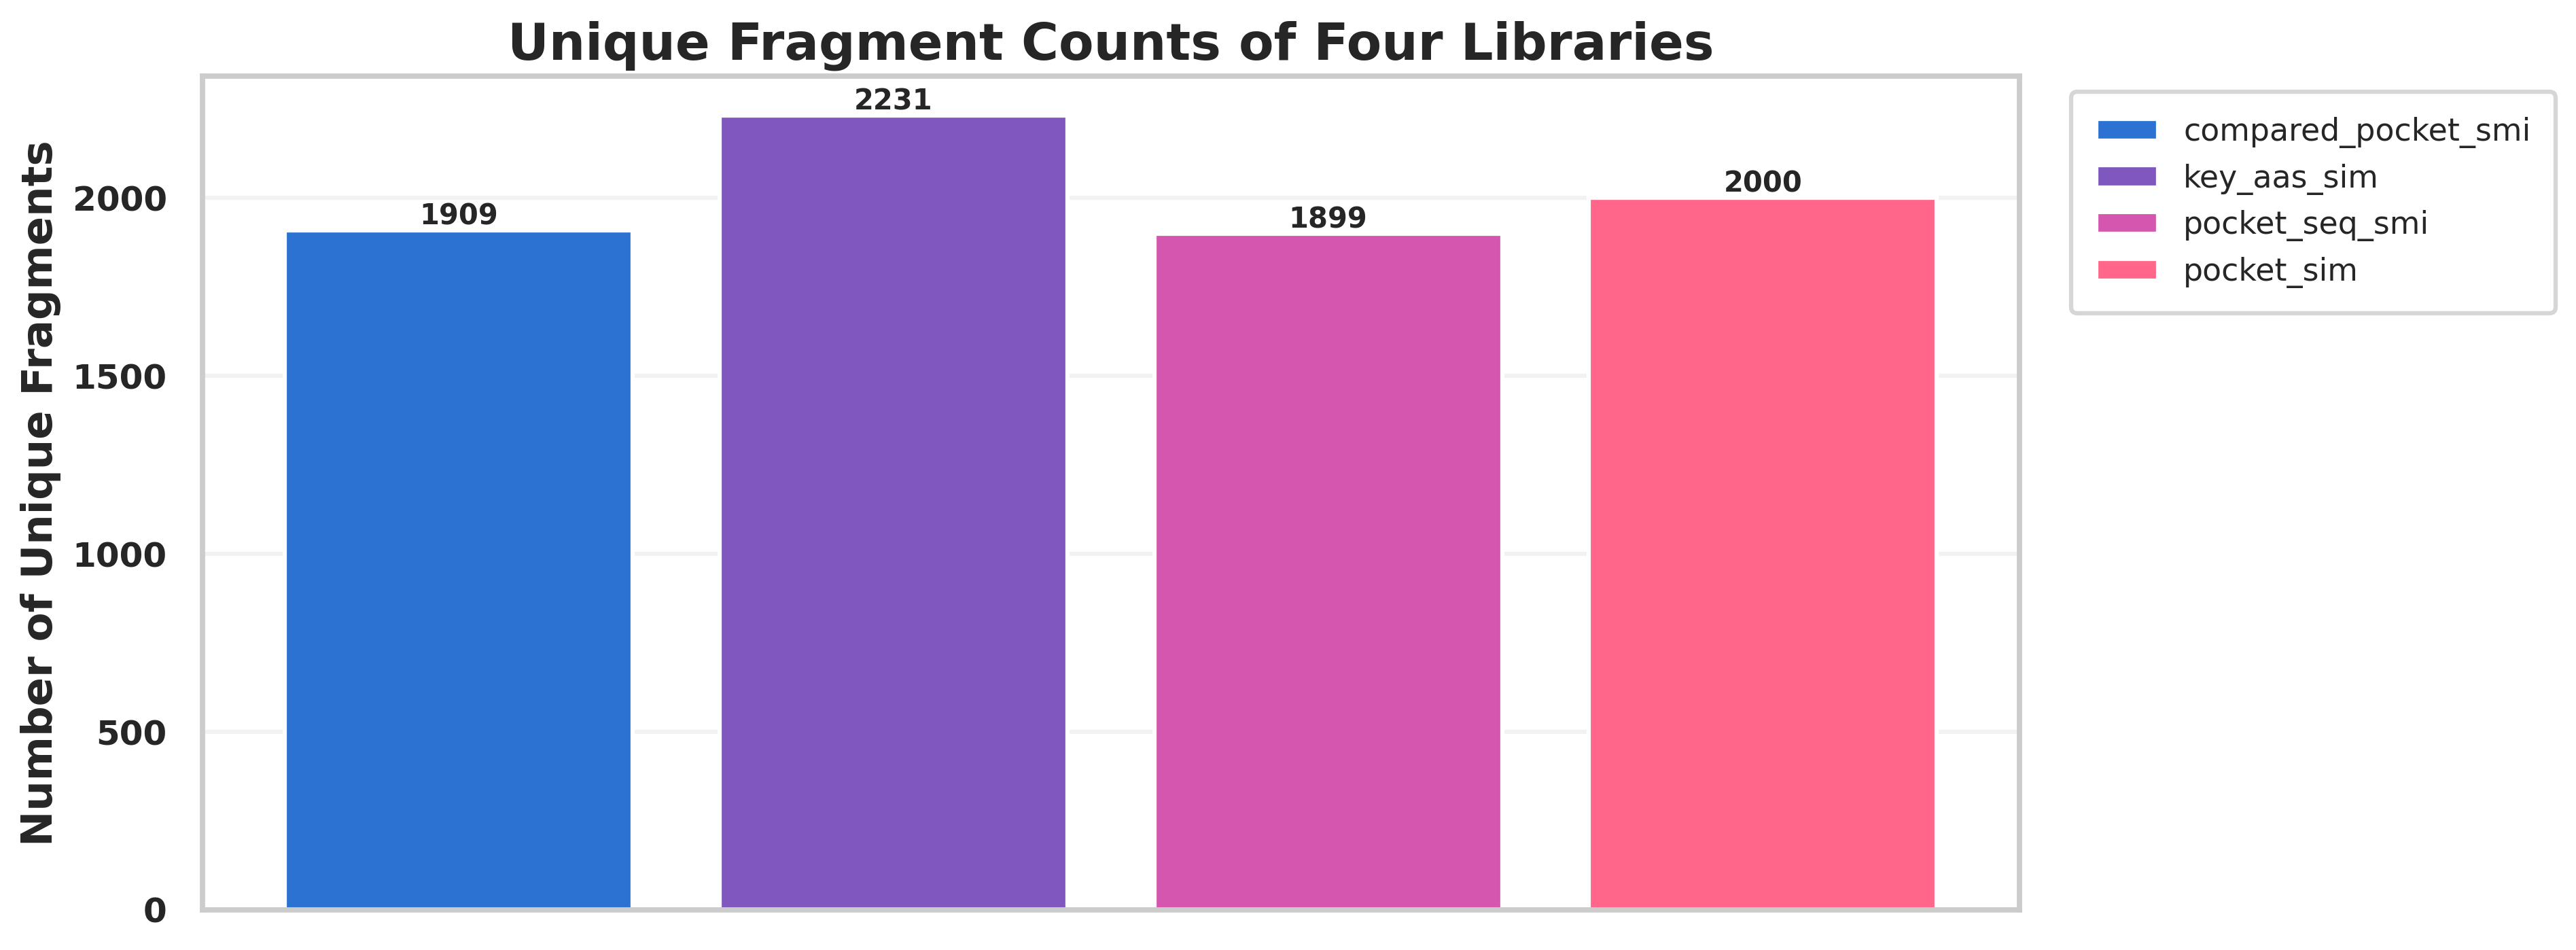

File Name                                     | Total Rows | Unique Fragments
------------------------------------------------------------
compared_pocket_smi                           | 1909      | 1909
key_aas_sim                                   | 2231      | 2231
pocket_seq_smi                                | 1899      | 1899
pocket_sim                                    | 2000      | 2000


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 你的4个csv文件路径
file_paths = [
    "./result/fragment_library_file_by_compared_pocket_similarity_refined_1000.csv",
    "./result/fragment_library_file_by_keyaas_overlap_descending.csv",
    "./result/fragment_library_file_by_pocket_seq_similarity.csv",
    "./result/fragment_library_file_by_pocket_similarity.csv"
]
# 自定义4组颜色
colors = ['#2B72D2', '#7F57BF', '#D456AE', '#FF668A']

# 存储结果
file_labels = ['compared_pocket_smi', 'key_aas_sim', 'pocket_seq_smi', 'pocket_sim']
total_rows = []       # 每个文件fragment列总行数（包含重复片段）
unique_frags = []     # 每个文件不重复fragment数量

for path in file_paths:
    df = pd.read_csv(path)
    # # 简化文件名作为图例标签
    # short_name = path.split("by_")[-1].replace(".csv", "")
    # file_labels.append(short_name)

    all_count = len(df["fragment"])
    uniq_count = df["fragment"].nunique()
    total_rows.append(all_count)
    unique_frags.append(uniq_count)

# ---------------------- 绘图：隐藏X轴标签，图例放在图右侧外部 ----------------------
# 加宽画布，给右侧图例留出空间
plt.figure(figsize=(13, 5), dpi=300)
bars = plt.bar(range(len(file_labels)), unique_frags, color=colors)

# 柱子顶部标注数值
for bar in bars:
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, val, str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Unique Fragment Counts of Four Libraries", fontsize=18, weight="bold")
# Y轴标签加粗
plt.ylabel("Number of Unique Fragments", fontsize=15, weight="bold")
# Y轴刻度字体加粗
plt.tick_params(axis='y', labelsize=12)
for tick in plt.gca().get_yticklabels():
    tick.set_fontweight("bold")
plt.grid(axis="y", alpha=0.25)

# 隐藏x轴刻度与文字标签
plt.xticks([])

# 图例加大字号
plt.legend(
    bars,
    file_labels,
    fontsize=11,        # 放大图例文字
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    borderpad=0.8       # 图例内边距，放大图例整体
)

# 调整布局防止图例被截断
plt.tight_layout()
plt.savefig("./result/fragment_unique_count_bar.png", bbox_inches="tight", dpi=300)
plt.show()

# 打印统计表格
print("="*60)
print(f"{'File Name':<45} | Total Rows | Unique Fragments")
print("-"*60)
for lab, row, uniq in zip(file_labels, total_rows, unique_frags):
    print(f"{lab:<45} | {row:<9} | {uniq}")
print("="*60)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.DataStructs import ConvertToNumpyArray

# 设置全局绘图风格，保证图片美观
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# ---------------------- 1. 读取原始配体数据 ----------------------
fragments_df = pd.read_csv('./result/fragment_library_file_by_pocket_similarity.csv')
# 提取第一列的原始配体SMILES，去重
original_smiles = fragments_df.iloc[:, 0].dropna().unique().tolist()
print(f"去重后原始配体数量：{len(original_smiles)}")

# ---------------------- 2. 读取生成分子数据 ----------------------
new_molecules_df = pd.read_csv('./result/new_molecules_file_by_pocket_similarity_filter_10000.csv')
# 提取最后一列的生成分子SMILES
new_smiles = new_molecules_df.iloc[:, -1].dropna().tolist()
print(f"生成分子数量：{len(new_smiles)}")

# ---------------------- 3. 过滤无效SMILES（解析失败的分子） ----------------------
def filter_valid_smiles(smiles_list):
    valid_smiles = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                valid_smiles.append(smi)
        except:
            continue
    return valid_smiles

original_smiles = filter_valid_smiles(original_smiles)
new_smiles = filter_valid_smiles(new_smiles)
print(f"有效原始配体数量：{len(original_smiles)}")
print(f"有效生成分子数量：{len(new_smiles)}")

FileNotFoundError: [Errno 2] No such file or directory: './KIT/KIT_fragments_file_by_compared_pocket_similarity_refined_1000_nik.csv'

In [24]:
# 定义ECFP指纹生成函数（半径2=ECFP4，2048位）
def generate_ecfp4_fingerprint(smiles_list):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        # 生成Morgan指纹（ECFP4）
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        # 转为numpy数组，方便后续计算
        fp_array = np.zeros((1,), dtype=np.int8)
        ConvertToNumpyArray(fp, fp_array)
        fps.append(fp_array)
    return np.array(fps)

# 生成原始配体和生成分子的指纹
original_fps = generate_ecfp4_fingerprint(original_smiles)
new_fps = generate_ecfp4_fingerprint(new_smiles)
print(f"原始配体指纹矩阵形状：{original_fps.shape}")
print(f"生成分子指纹矩阵形状：{new_fps.shape}")

原始配体指纹矩阵形状：(2000, 2048)
生成分子指纹矩阵形状：(10000, 2048)


In [25]:
# 批量计算Tanimoto相似性，返回形状为[生成分子数量, 原始配体数量]的相似性矩阵
def calculate_tanimoto_matrix(new_fps, original_fps):
    # 计算分子的特征数（指纹中1的数量）
    new_fp_sum = new_fps.sum(axis=1, keepdims=True)  # [n_new, 1]
    original_fp_sum = original_fps.sum(axis=1, keepdims=True)  # [n_original, 1]

    # 计算共同特征数（矩阵点积）
    intersection = np.dot(new_fps, original_fps.T)  # [n_new, n_original]

    # 计算Tanimoto相似性
    union = new_fp_sum + original_fp_sum.T - intersection
    tanimoto_matrix = intersection / union

    return tanimoto_matrix

# 计算相似性矩阵
tanimoto_matrix = calculate_tanimoto_matrix(new_fps, original_fps)
# 每个生成分子取与原始配体的最大相似性
max_similarity = tanimoto_matrix.max(axis=1)
print(f"最大相似性数组形状：{max_similarity.shape}")

最大相似性数组形状：(10000,)


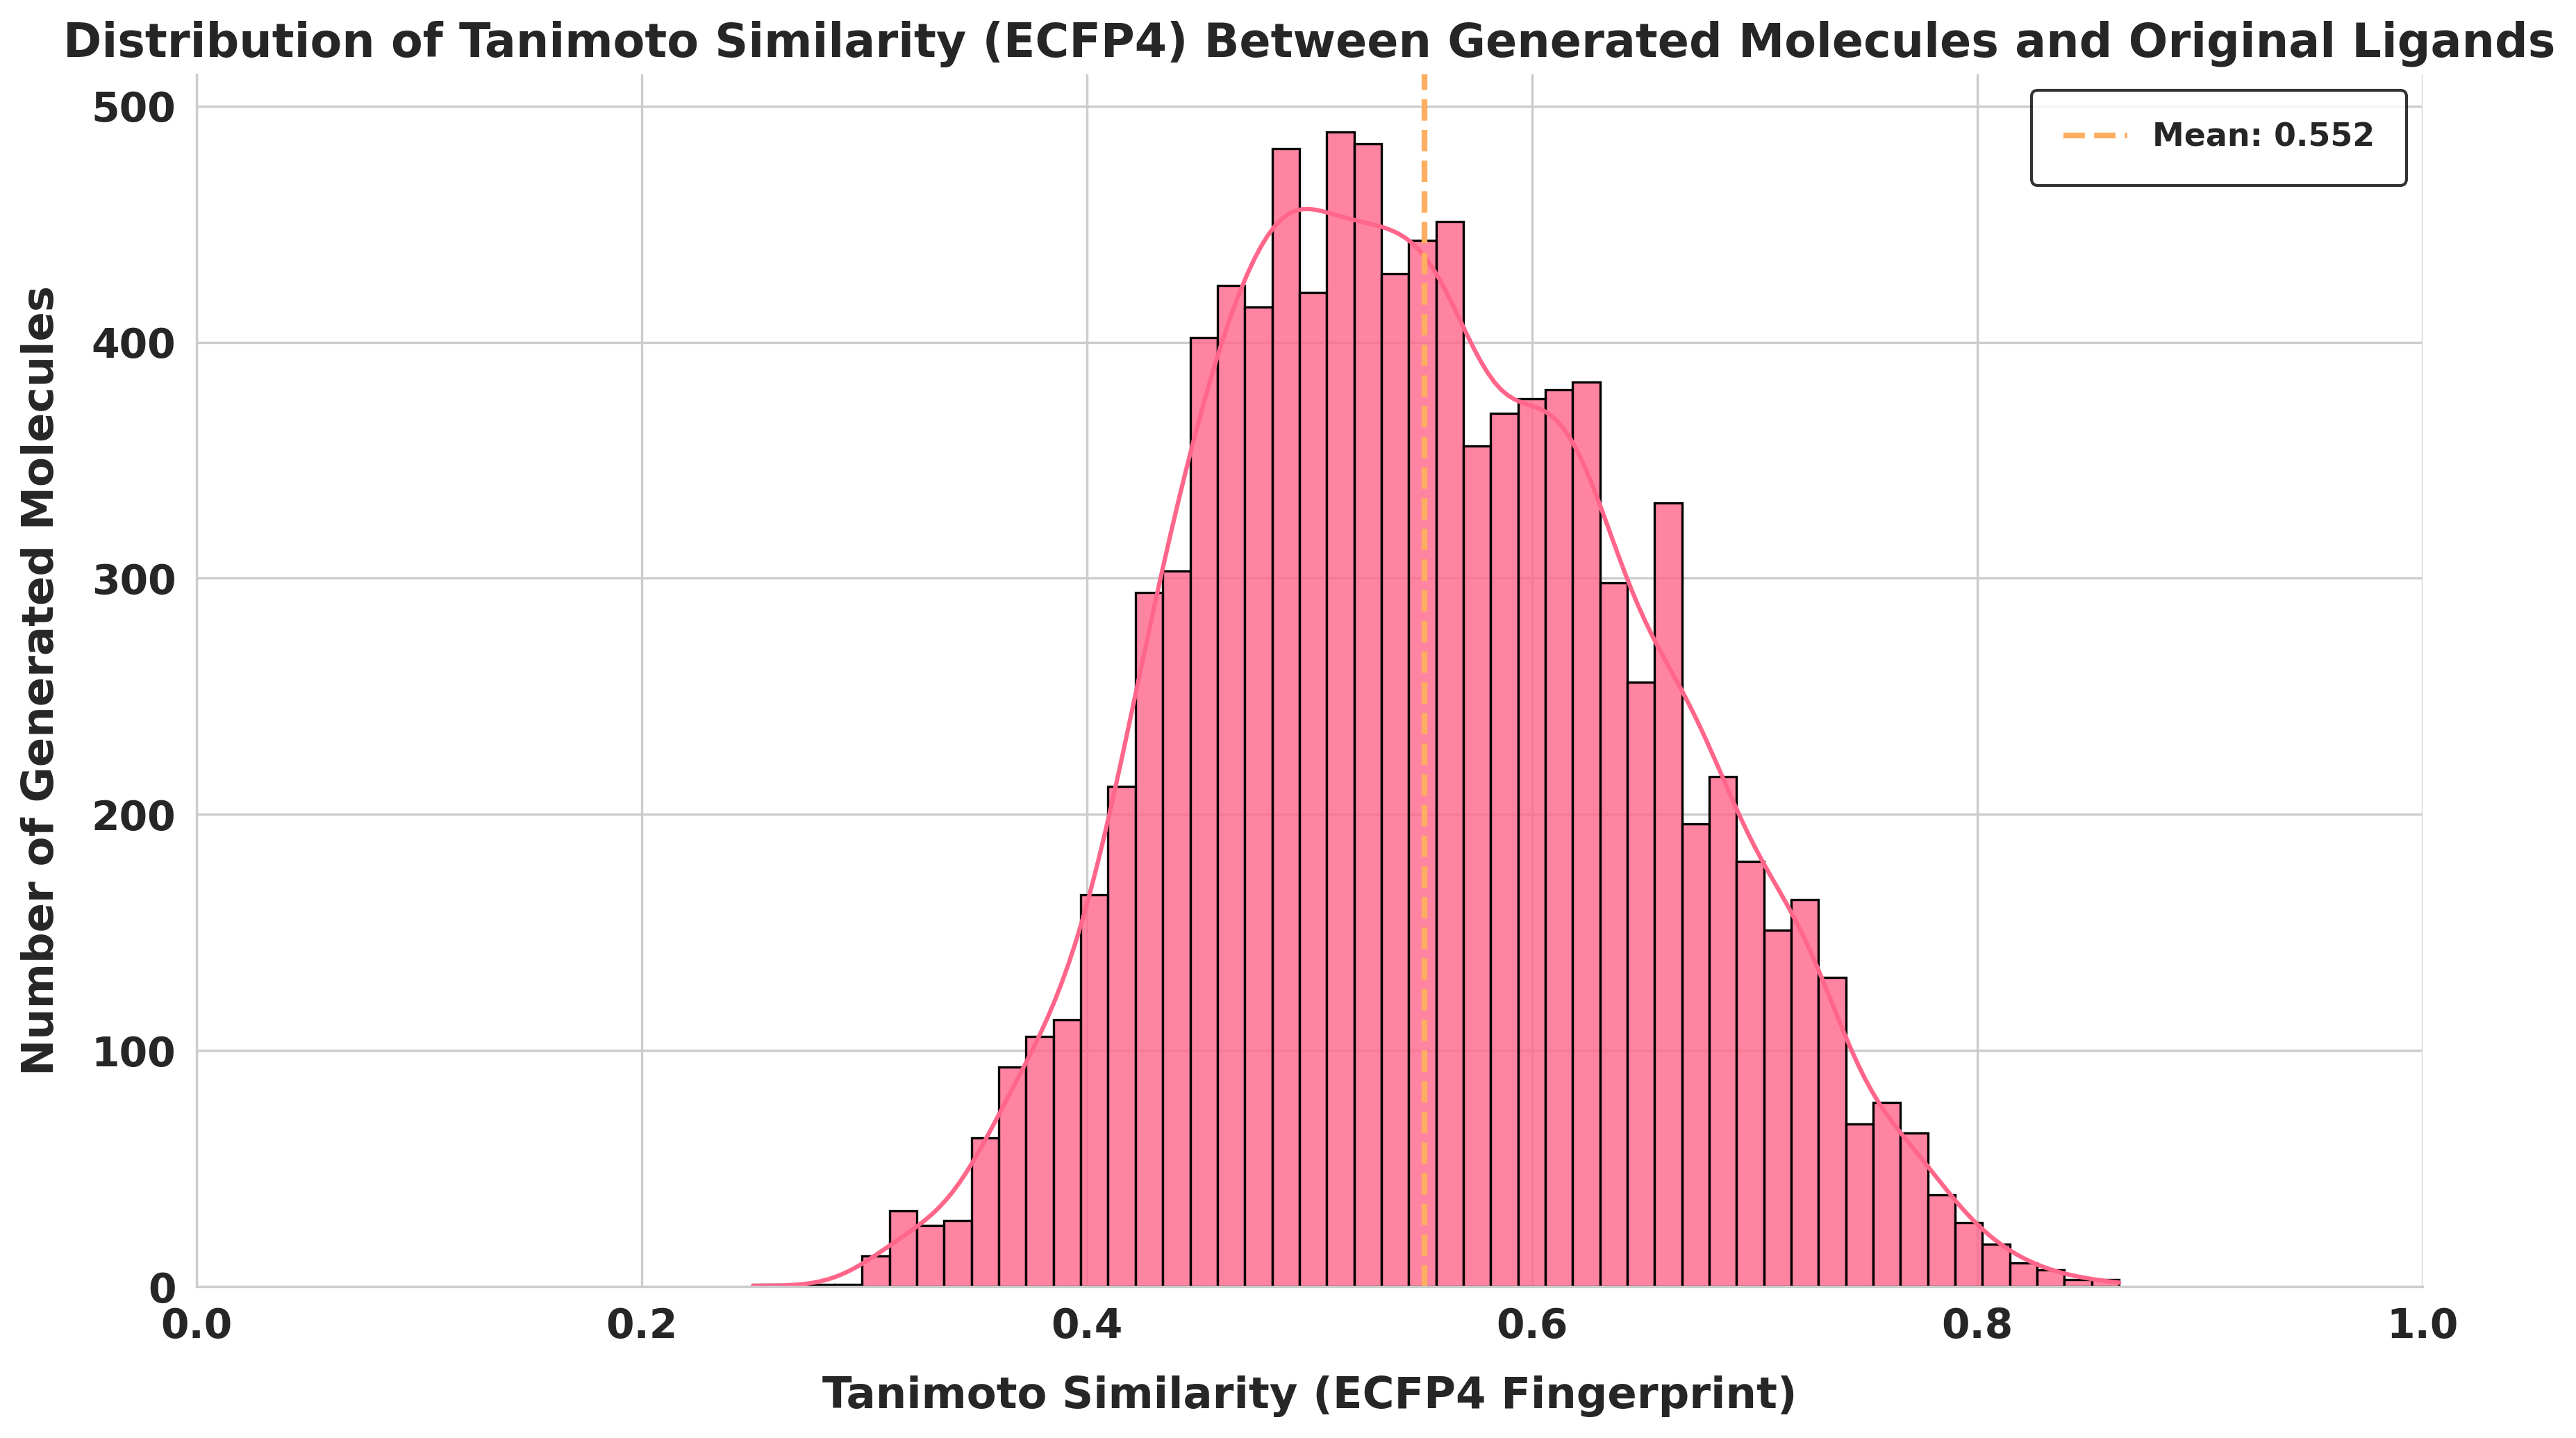

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 7), dpi=300)

# 绘制直方图+核密度曲线
ax = sns.histplot(
    max_similarity,
    bins=50,
    kde=True,
    color='#FF668A',
    edgecolor='black',
    alpha=0.8,
    linewidth=0.8
)

# 添加均值参考线
mean_val = np.mean(max_similarity)
ax.axvline(mean_val, color='#fdae61', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')

# 图表设置
ax.set_title('Distribution of Tanimoto Similarity (ECFP4) Between Generated Molecules and Original Ligands', fontsize=16, fontweight='bold')
# X轴标签加粗
ax.set_xlabel('Tanimoto Similarity (ECFP4 Fingerprint)', fontsize=15, fontweight='bold', labelpad=10)
# Y轴标签加粗
ax.set_ylabel('Number of Generated Molecules', fontsize=15, fontweight='bold', labelpad=10)
# 坐标轴刻度数字也加粗
plt.setp(ax.get_xticklabels(), fontweight='bold', fontsize=14)
plt.setp(ax.get_yticklabels(), fontweight='bold', fontsize=14)

# 放大图例：字号+内边距+边框粗细
ax.legend(
    fontsize=16, # 文字放大
    prop={'weight': 'bold', 'size': 11},
    borderpad=1.0,      # 图例内部上下左右留白
    handletextpad=0.8,  # 线条和文字间距
    frameon=True,
    edgecolor='black'
)
ax.set_xlim(0, 1)

# 美化边框
sns.despine()
plt.tight_layout()

# 保存图片
plt.savefig('similarity_distribution_ECFP4_pocket_similarity.png', dpi=300, bbox_inches='tight')
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

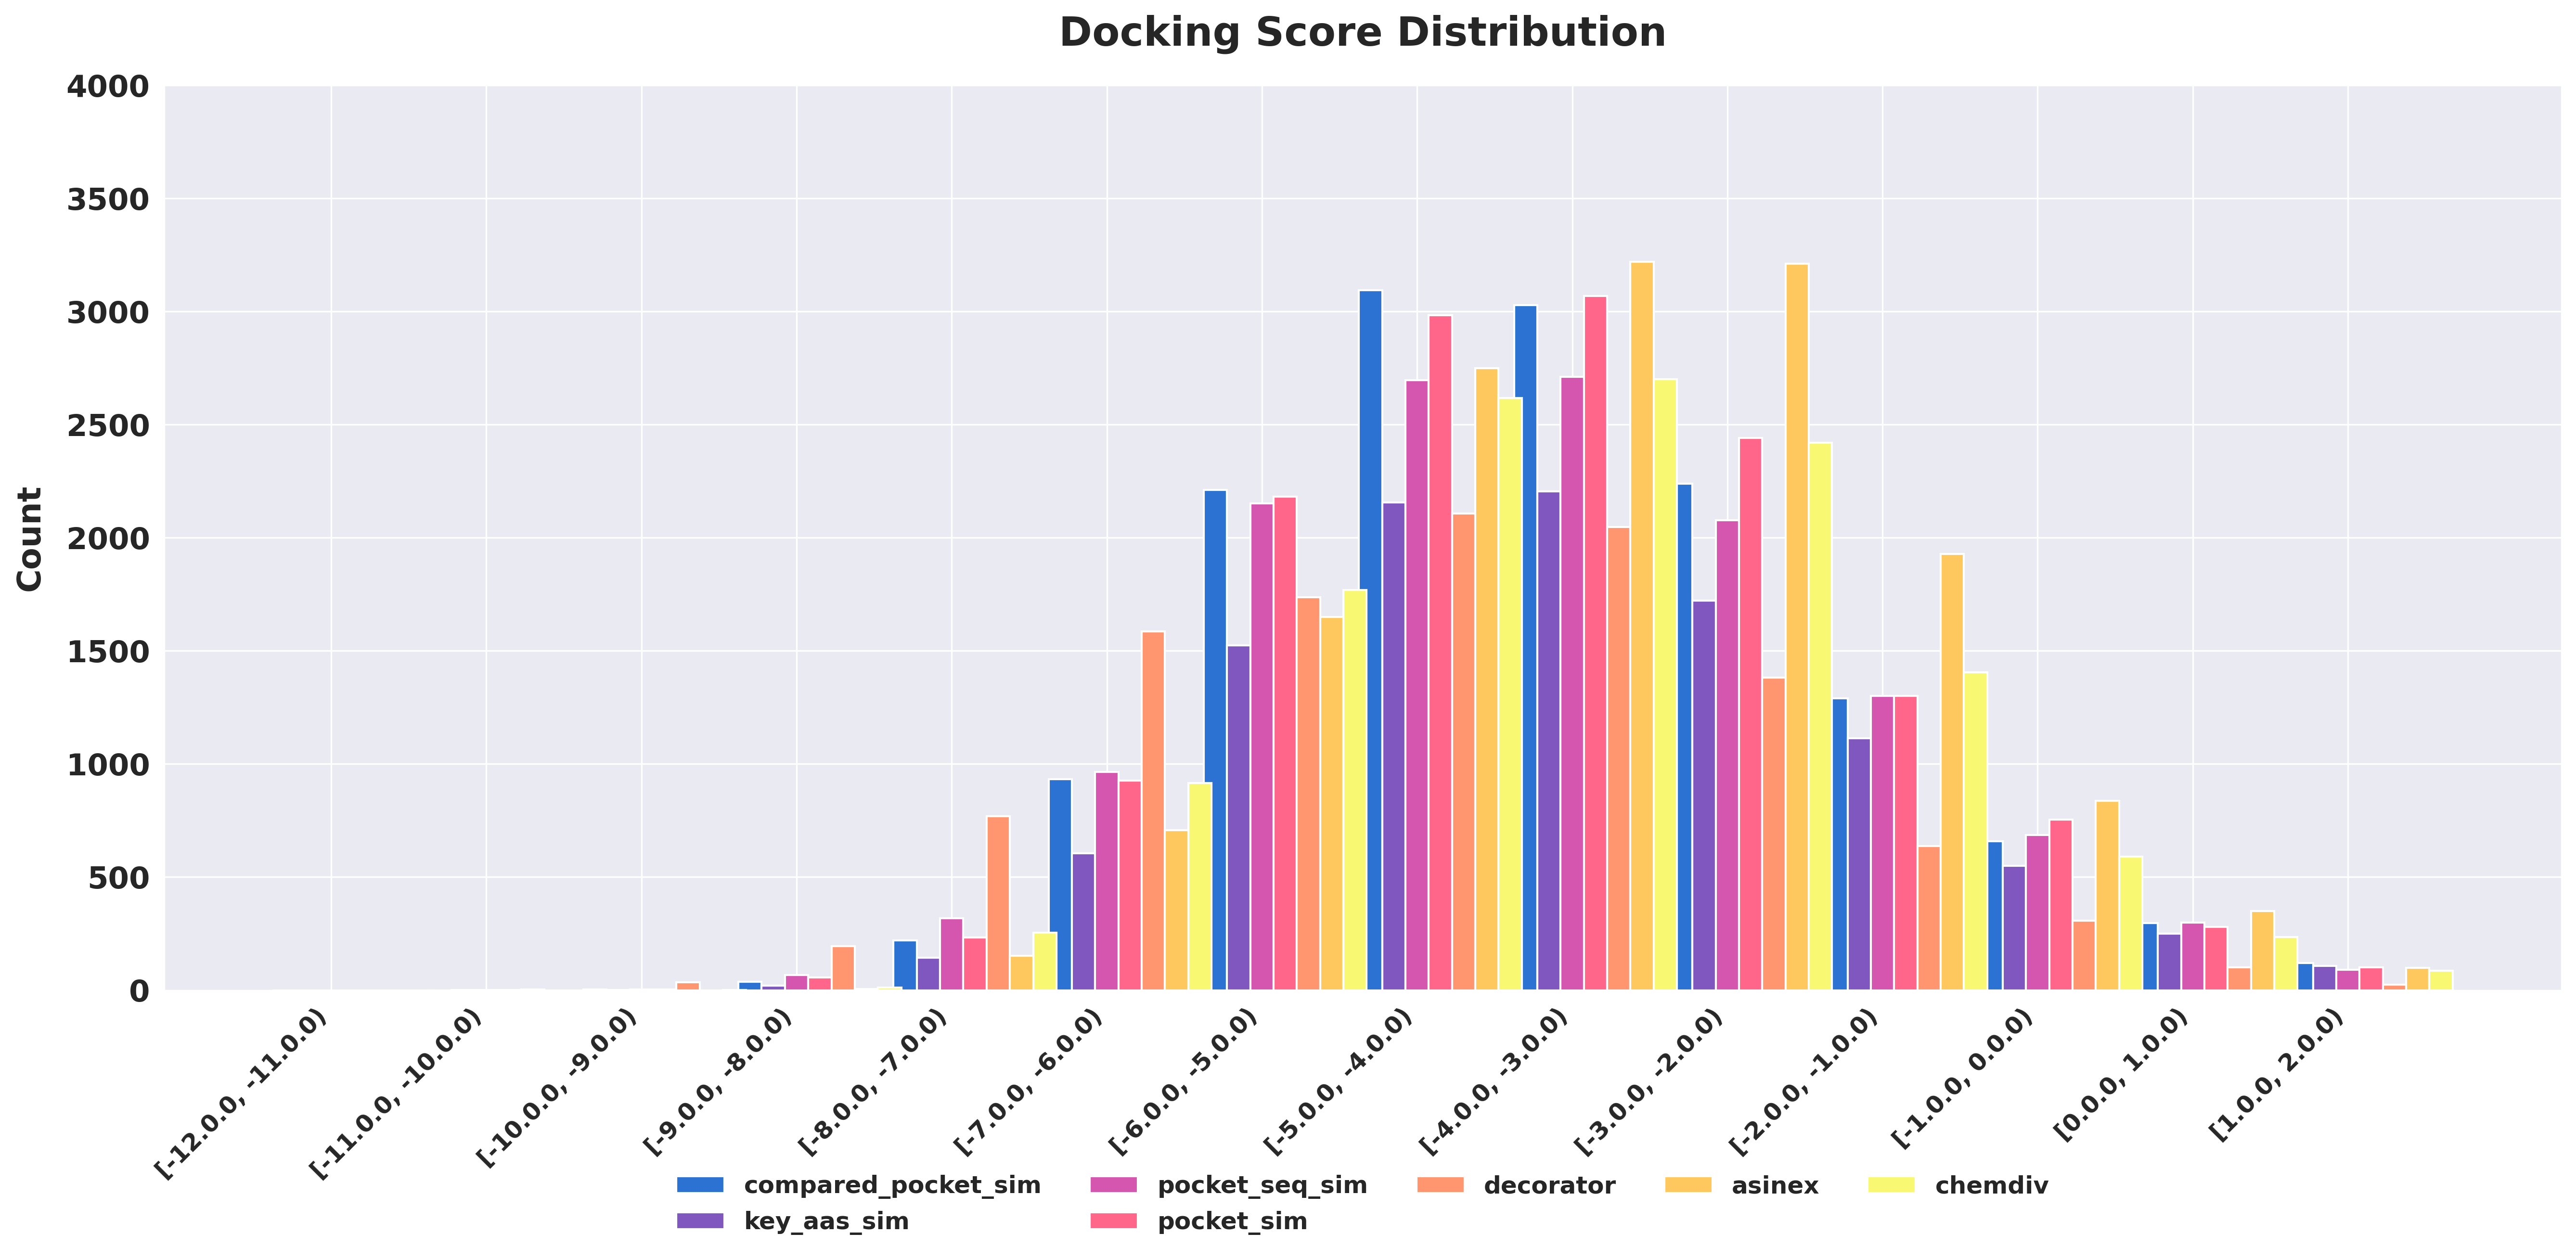

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 文件与颜色映射
file_mapping = {
    "compared_pocket_sim": "./ligpre/split_output/glide-dock_XP_compared_pocket_similarity_pv.maegz.csv",
    "key_aas_sim": "./ligpre/split_output/glide-dock_XP_keyaas_similarity_pv.maegz.csv",
    "pocket_seq_sim": "./ligpre/split_output/glide-dock_XP_pocket_seq_similarity_pv.maegz.csv",
    "pocket_sim": "./ligpre/split_output/glide-dock_XP_pocket_similarity_pv.maegz.csv",
    "decorator": "./ligpre/split_output/glide-dock_XP_decorator_pv.maegz.csv",
    "asinex": "./ligpre/split_output/glide-dock_XP_1_random_asinex_pv.maegz.csv",
    "chemdiv": "./ligpre/split_output/glide-dock_XP_1_random_chemdiv_pv.maegz.csv"
}

custom_color_dict = {
    "compared_pocket_sim": "#2B72D2",
    "key_aas_sim": "#7F57BF",
    "pocket_seq_sim": "#D456AE",
    "pocket_sim": "#FF668A",
    "decorator": "#FF9670",
    "asinex": "#FFC85F",
    "chemdiv": "#F9F872",
}

# 2. 分箱区间
bins = np.arange(-12, 2.1, 1)
bin_labels = [f"[{i}.0, {i+1}.0)" for i in bins[:-1]]

# 3. 读取数据统计分箱
counts_dict = {}
for name, file_path in file_mapping.items():
    df = pd.read_csv(file_path, low_memory=False)
    docking_scores = df["docking score"].dropna()
    counts = pd.cut(
        docking_scores,
        bins=bins,
        labels=bin_labels,
        right=False
    ).value_counts().sort_index()
    counts_dict[name] = counts  # 修复之前遗漏赋值bug

# 4. 全局绘图设置
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 300
# 有效参数：坐标轴标签加粗
plt.rcParams['axes.labelweight'] = 'bold'

# 加宽画布防止x轴标签拥挤
plt.figure(figsize=(18, 9))

x = np.arange(len(bin_labels))
bar_width = 0.15

# 绘制分组柱状图
for idx, (name, counts) in enumerate(counts_dict.items()):
    offset = bar_width * (idx - 2)
    plt.bar(
        x + offset,
        counts,
        width=bar_width,
        label=name,
        color=custom_color_dict[name]  # 修复之前传字典的错误
    )

# 5. 坐标轴配置：旋转防拥挤 + 全部加粗
# X轴：45度右对齐，刻度文字加粗
plt.xticks(x, bin_labels, rotation=45, ha='right', fontweight='bold')
# Y轴刻度文字加粗
plt.yticks(fontsize=15, fontweight='bold')

# 坐标轴名称，加粗+加大间距
plt.ylabel("Count", fontsize=16, fontweight='bold', labelpad=10)

# 标题加粗
plt.title("Docking Score Distribution", fontsize=20, fontweight='bold', pad=20)

# 图例调整到底部，避免遮挡
plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=5,
    fontsize=15,
    prop={"weight": "bold"}
)

plt.ylim(0, 4000)
plt.tight_layout()

# 保存并展示
plt.savefig("docking_score_histogram1.png", dpi=300, bbox_inches="tight")
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

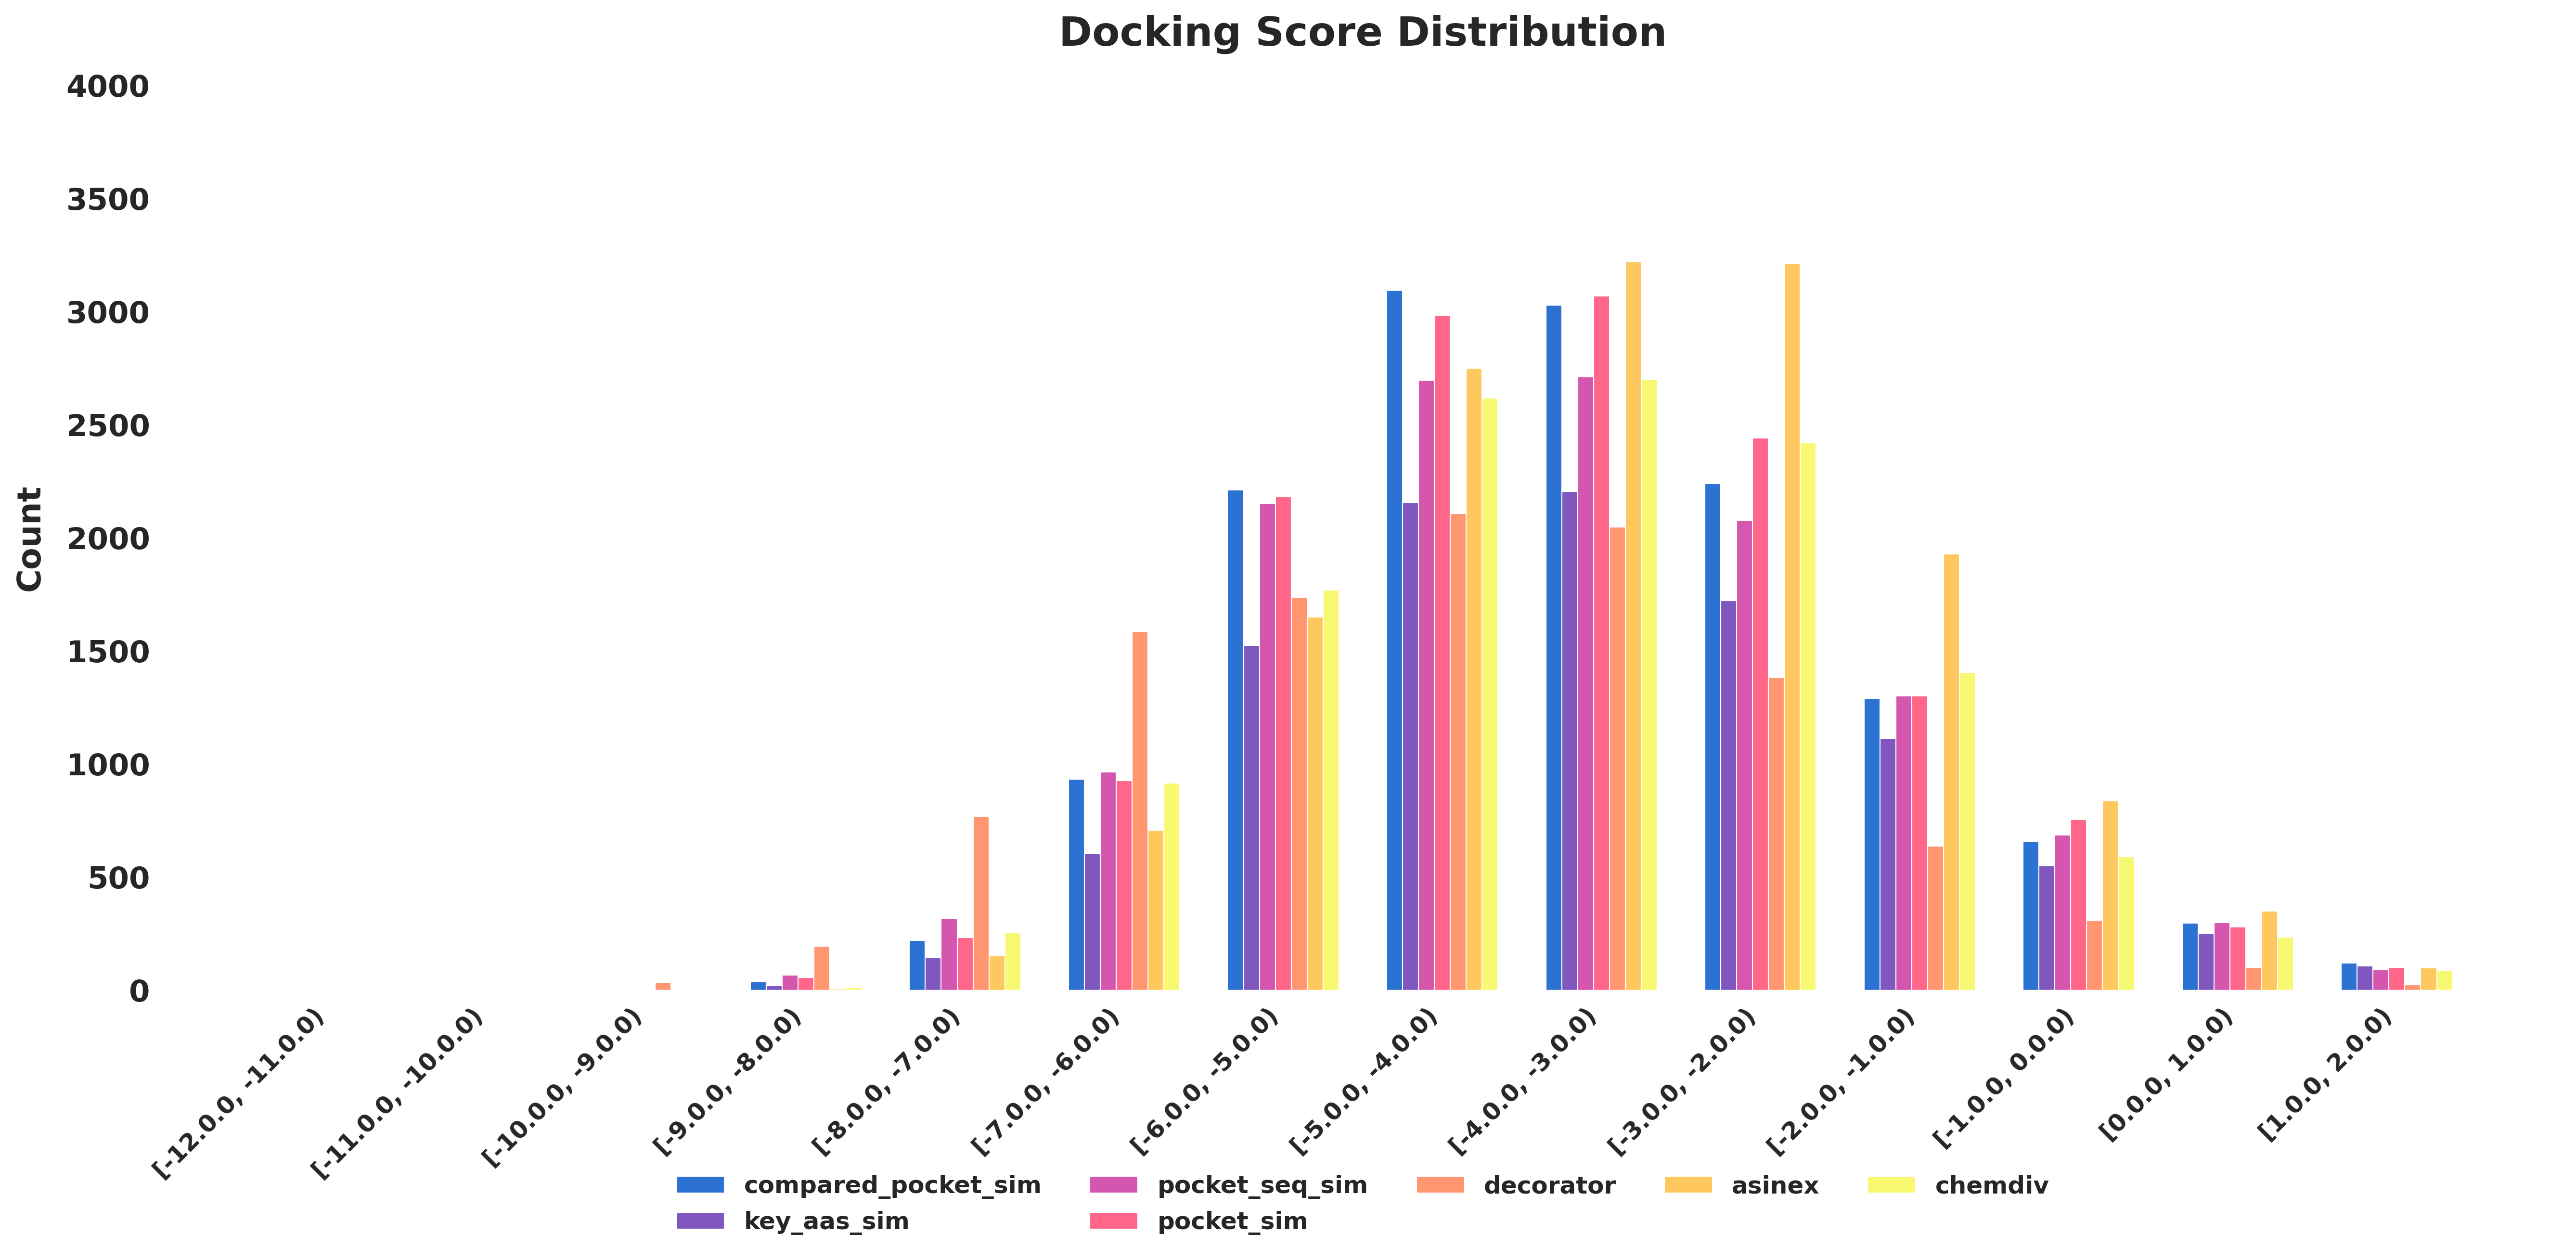

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 文件与颜色映射
file_mapping = {
    "compared_pocket_sim": "./ligpre/split_output/glide-dock_XP_compared_pocket_similarity_pv.maegz.csv",
    "key_aas_sim": "./ligpre/split_output/glide-dock_XP_keyaas_similarity_pv.maegz.csv",
    "pocket_seq_sim": "./ligpre/split_output/glide-dock_XP_pocket_seq_similarity_pv.maegz.csv",
    "pocket_sim": "./ligpre/split_output/glide-dock_XP_pocket_similarity_pv.maegz.csv",
    "decorator": "./ligpre/split_output/glide-dock_XP_decorator_pv.maegz.csv",
    "asinex": "./ligpre/split_output/glide-dock_XP_1_random_asinex_pv.maegz.csv",
    "chemdiv": "./ligpre/split_output/glide-dock_XP_1_random_chemdiv_pv.maegz.csv"
}

custom_color_dict = {
    "compared_pocket_sim": "#2B72D2",
    "key_aas_sim": "#7F57BF",
    "pocket_seq_sim": "#D456AE",
    "pocket_sim": "#FF668A",
    "decorator": "#FF9670",
    "asinex": "#FFC85F",
    "chemdiv": "#F9F872",
}

# 2. 分箱区间
bins = np.arange(-12, 2.1, 1)
bin_labels = [f"[{i}.0, {i+1}.0)" for i in bins[:-1]]

# 3. 读取数据统计分箱
counts_dict = {}
for name, file_path in file_mapping.items():
    df = pd.read_csv(file_path, low_memory=False)
    docking_scores = df["docking score"].dropna()
    counts = pd.cut(
        docking_scores,
        bins=bins,
        labels=bin_labels,
        right=False
    ).value_counts().sort_index()
    counts_dict[name] = counts

# 4. 全局绘图设置：全白背景 + 无网格
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 300
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.facecolor'] = 'white'       # 坐标轴背景纯白
plt.rcParams['figure.facecolor'] = 'white'     # 画布背景纯白
plt.rcParams['axes.grid'] = False              # 关闭网格线

plt.figure(figsize=(18, 9))

x = np.arange(len(bin_labels))
bar_width = 0.10   # 从 0.15 减小到 0.10，7 根总宽 0.7，留出间距

# 绘制分组柱状图，offset 居中对齐
n_files = len(counts_dict)
for idx, (name, counts) in enumerate(counts_dict.items()):
    offset = bar_width * (idx - (n_files - 1) / 2)
    plt.bar(
        x + offset,
        counts,
        width=bar_width,
        label=name,
        color=custom_color_dict[name],
        edgecolor='white',   # 白色描边，进一步区分相邻柱子
        linewidth=0.5
    )

# 5. 坐标轴配置
plt.xticks(x, bin_labels, rotation=45, ha='right', fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')

plt.ylabel("Count", fontsize=16, fontweight='bold', labelpad=10)
plt.title("Docking Score Distribution", fontsize=20, fontweight='bold', pad=20)

plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=5,
    fontsize=15,
    prop={"weight": "bold"}
)

plt.ylim(0, 4000)
plt.tight_layout()

plt.savefig("docking_score_histogram1.png", dpi=300, bbox_inches="tight",
            facecolor='white')   # 保存时也强制白底
plt.show()